# Augmentation Benchmark: MONAI vs TorchIO

One-by-one comparison on subject **1THB011**, full volume (386×340×228).  
All transforms run at `prob=1.0` (training default: 0.33).  
Each cell times `N_RUNS=3` runs and shows the mid-axial slice.

| # | MONAI | TorchIO | Notes |
|---|-------|---------|-------|
| 1 | Spacingd | tio.Resample | |
| 2 | SpatialPadd | tio.CropOrPad | SpatialPadd only pads; CropOrPad also crops |
| 3 | ScaleIntensityRanged | tio.RescaleIntensity | CT HU → [0,1] |
| 4 | RandAxisFlipd | tio.RandomFlip | |
| 5 | RandRotate90d | custom TioRotate90 | No direct TorchIO equiv |
| 6 | RandSimulateLowResolutiond | tio.RandomAnisotropy | |
| 7 | RandGaussianNoised | tio.RandomNoise | |
| 8 | RandBiasFieldd | tio.RandomBiasField | |
| 9 | RandGibbsNoised | tio.RandomGhosting | Different artifacts! |
| 10 | RandAdjustContrastd | tio.RandomGamma | |
| 11 | RandGaussianSmoothd | tio.RandomBlur | |
| 12 | RandGaussianSharpend | custom (unsharp mask) | No direct TorchIO equiv |
| 13 | RandAffined | tio.RandomAffine | |

## Setup

In [1]:
%matplotlib inline
import copy, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import torch
import torchio as tio
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    RandAdjustContrastd,
    RandAffined,
    RandAxisFlipd,
    RandBiasFieldd,
    RandGaussianNoised,
    RandGaussianSharpend,
    RandGaussianSmoothd,
    RandGibbsNoised,
    RandRotate90d,
    RandSimulateLowResolutiond,
    ScaleIntensityRanged,
    Spacingd,
    SpatialPadd,
)

ROOT = Path("/gpfs/accounts/jjparkcv_root/jjparkcv98/minsukc/MRI2CT/SynthRAD/1.5mm_registered_flat_masked/1THB011")
CT_PATH = str(ROOT / "ct.nii")
MASK_PATH = str(ROOT / "mask.nii")
SPACING = (1.5, 1.5, 1.5)
CROP_SIZE = (128, 128, 128)  # only used for SpatialPadd / CropOrPad benchmark
N_RUNS = 3
OUT_DIR = Path("../tests/aug_benchmark")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Setup complete.


## Load & preprocess data (full volume)

In [2]:
# Normalized base (HU → [0,1])
monai_base = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
        ScaleIntensityRanged(keys="image", a_min=-1024, a_max=1024, b_min=0.0, b_max=1.0, clip=True),
    ]
)({"image": CT_PATH, "label": MASK_PATH})

# Raw (unnormalized) — used only for benchmark #3
monai_raw = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        EnsureTyped(keys=["image", "label"]),
    ]
)({"image": CT_PATH, "label": MASK_PATH})

_full = tio.Subject(image=tio.ScalarImage(CT_PATH), label=tio.LabelMap(MASK_PATH))
tio_base = tio.RescaleIntensity(in_min_max=(-1024, 1024), out_min_max=(0, 1), include=["image"])(copy.deepcopy(_full))
tio_raw = copy.deepcopy(_full)

print(f"MONAI  shape={tuple(monai_base['image'].shape)}  range=[{monai_base['image'].min():.2f}, {monai_base['image'].max():.2f}]")
print(f"TorchIO shape={tuple(tio_base['image'].shape)}  range=[{tio_base['image'].data.min():.2f}, {tio_base['image'].data.max():.2f}]")

MONAI  shape=(1, 386, 340, 228)  range=[0.00, 1.00]
TorchIO shape=(1, 386, 340, 228)  range=[0.00, 1.81]


## Helpers & custom transforms

In [ ]:
def bench_monai(t, base, n=N_RUNS):
    times, out = [], None
    for _ in range(n):
        d = copy.deepcopy(base)
        t0 = time.perf_counter()
        out = t(d)
        times.append(time.perf_counter() - t0)
    return out, float(np.mean(times))


def bench_tio(t, base, n=N_RUNS):
    times, out = [], None
    for _ in range(n):
        s = copy.deepcopy(base)
        t0 = time.perf_counter()
        out = t(s)
        times.append(time.perf_counter() - t0)
    return out, float(np.mean(times))


def mid_m(d):
    t = d["image"]
    if t.ndim == 4:
        t = t[0]
    return t[:, :, t.shape[2] // 2].numpy()


def mid_t(s):
    t = s["image"].data
    if t.ndim == 4:
        t = t[0]
    return t[:, :, t.shape[2] // 2].numpy()


orig = mid_m(monai_base)
results = []  # (name, monai_ms, tio_ms)


def show(name, monai_fn, tio_fn, m_base=None, t_base=None, orig_slice=None):
    mb = m_base if m_base is not None else monai_base
    tb = t_base if t_base is not None else tio_base
    _orig = orig_slice if orig_slice is not None else orig

    m_out, m_t = bench_monai(monai_fn, mb)
    t_out, t_t = bench_tio(tio_fn, tb)
    results.append((name, m_t * 1000, t_t * 1000))
    print(f"MONAI: {m_t * 1000:.1f} ms  |  TorchIO: {t_t * 1000:.1f} ms  (avg {N_RUNS} runs)")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, img, title in zip(
        axes,
        [np.clip(_orig, 0, 1), np.clip(mid_m(m_out), 0, 1), np.clip(mid_t(t_out), 0, 1)],
        ["Original (pre-aug)", f"MONAI\n{m_t * 1000:.0f} ms", f"TorchIO\n{t_t * 1000:.0f} ms"],
    ):
        ax.imshow(img, cmap="gray", origin="lower")
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    fig.suptitle(name, fontsize=11, fontweight="bold")
    plt.tight_layout()
    safe = "".join(c if c.isalnum() or c in "_-" else "_" for c in name)
    plt.savefig(OUT_DIR / f"{safe}.png", dpi=120, bbox_inches="tight")
    plt.show()


class TioRotate90(tio.Transform):
    """Rotate 90°×k (k=1,2,3) in axial (H-W) plane."""

    def apply_transform(self, subject):
        k = int(torch.randint(1, 4, (1,)))
        for img in subject.get_images_dict().values():
            img.set_data(torch.rot90(img.data.clone(), k, dims=[1, 2]))
        return subject


class TioGaussianSharpen(tio.Transform):
    """Unsharp masking — no direct TorchIO equivalent."""

    def __init__(self, sigma=(0.5, 1.5), alpha=(0.5, 1.5), **kwargs):
        super().__init__(**kwargs)
        self.sigma = sigma
        self.alpha = alpha

    def apply_transform(self, subject):
        s = float(np.random.uniform(*self.sigma))
        a = float(np.random.uniform(*self.alpha))
        img = subject["image"]
        d = img.data[0].numpy().astype(np.float32)
        blurred = ndi.gaussian_filter(d, sigma=s)
        img.set_data(torch.from_numpy(np.clip(d + a * (d - blurred), 0, 1)[None]))
        return subject


print("Helpers ready.")

Helpers ready.


---
## 1. Spacingd vs tio.Resample
Data is already 1.5 mm isotropic, so no actual resampling occurs — pure overhead timing.

MONAI: 21.6 ms  |  TorchIO: 1160.5 ms  (avg 3 runs)


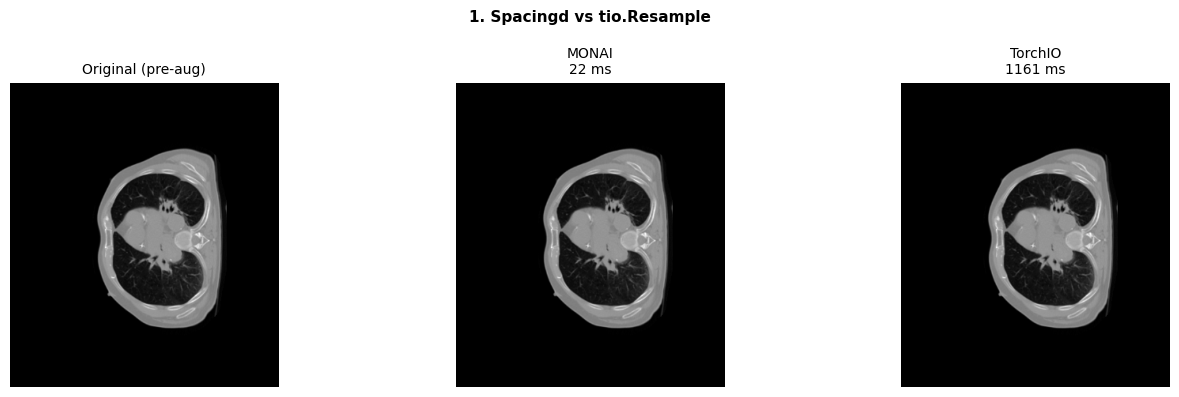

In [4]:
show(
    "1. Spacingd vs tio.Resample",
    Spacingd(keys=["image", "label"], pixdim=SPACING, mode=("bilinear", "nearest")),
    tio.Resample(target=SPACING, image_interpolation="linear", label_interpolation="nearest"),
)

---
## 2. SpatialPadd vs tio.CropOrPad
**Key difference:** `SpatialPadd` only pads to ≥ target size (no-op on 386×340×228 for target 128).  
`CropOrPad` crops the full volume **down** to exactly 128³.

MONAI: 12.5 ms  |  TorchIO: 25.2 ms  (avg 3 runs)


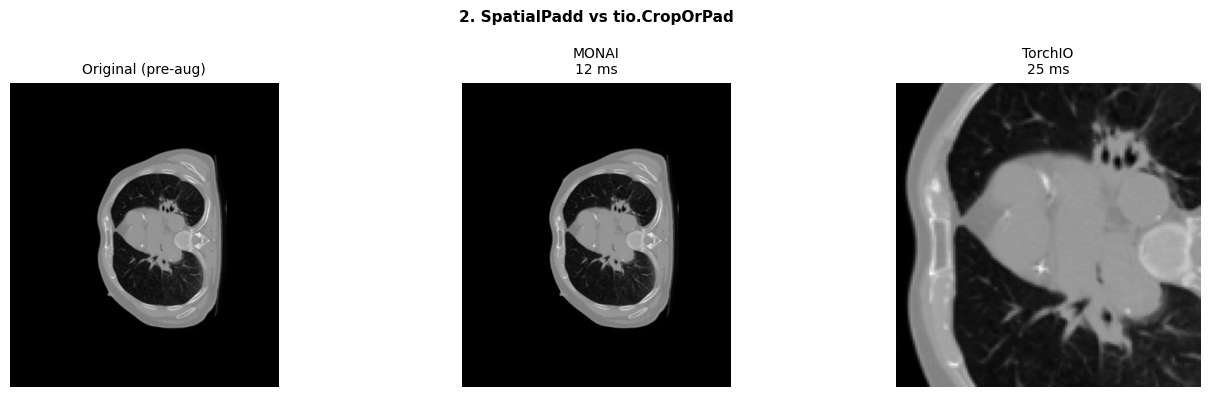

In [5]:
show(
    "2. SpatialPadd vs tio.CropOrPad",
    SpatialPadd(keys=["image", "label"], spatial_size=CROP_SIZE),
    tio.CropOrPad(CROP_SIZE),
)

---
## 3. ScaleIntensityRanged vs tio.RescaleIntensity
Maps CT HU range [-1024, 1024] → [0, 1] with clipping.  
Using raw (unnormalized) data as input so the effect is visible.

MONAI: 114.3 ms  |  TorchIO: 773.0 ms  (avg 3 runs)


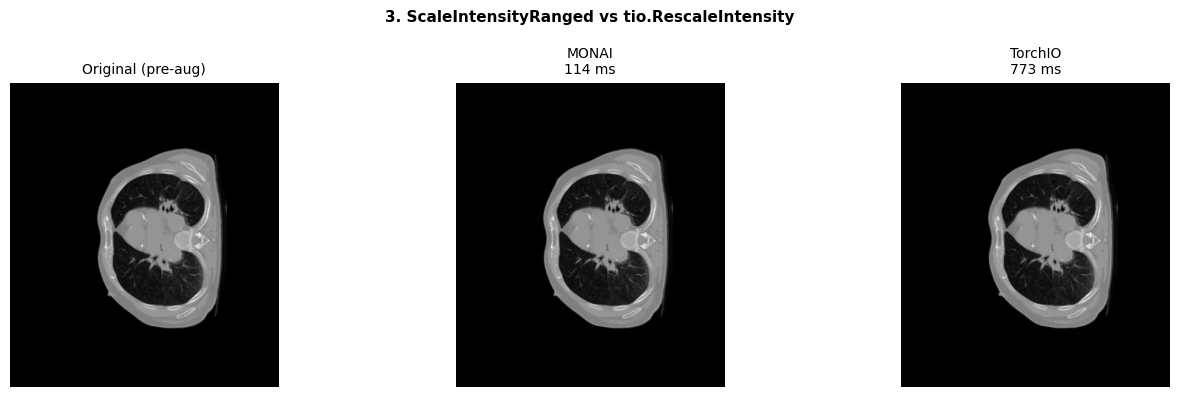

In [6]:
raw_display = (np.clip(mid_m(monai_raw), -1024, 1024) + 1024) / 2048.0
show(
    "3. ScaleIntensityRanged vs tio.RescaleIntensity",
    ScaleIntensityRanged(keys="image", a_min=-1024, a_max=1024, b_min=0.0, b_max=1.0, clip=True),
    tio.RescaleIntensity(in_min_max=(-1024, 1024), out_min_max=(0, 1), include=["image"]),
    m_base=monai_raw,
    t_base=tio_raw,
    orig_slice=raw_display,
)

---
## 4. RandAxisFlipd vs tio.RandomFlip
MONAI picks one random axis to flip; TorchIO flips each axis independently.

MONAI: 44.6 ms  |  TorchIO: 94.5 ms  (avg 3 runs)


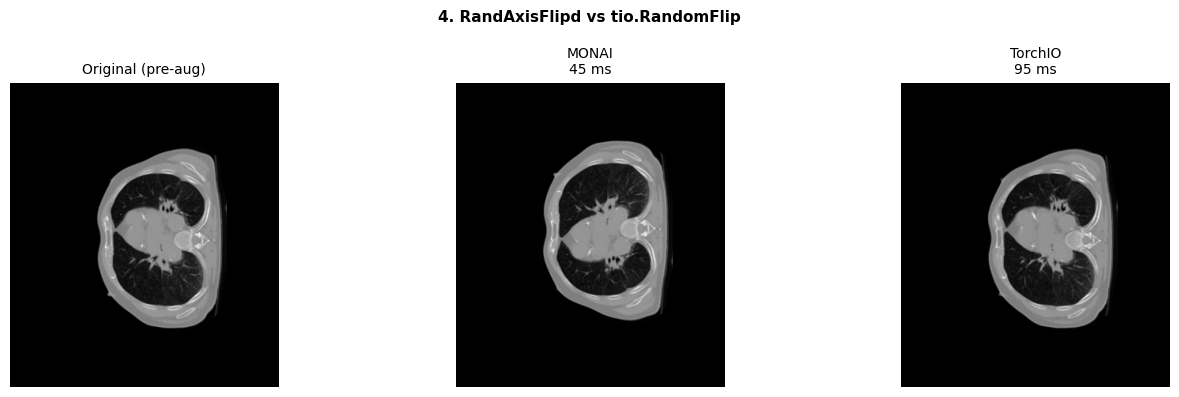

In [7]:
show(
    "4. RandAxisFlipd vs tio.RandomFlip",
    RandAxisFlipd(keys=["image", "label"], prob=1.0),
    tio.RandomFlip(axes=(0, 1, 2), flip_probability=0.5),
)

---
## 5. RandRotate90d vs custom TioRotate90
TorchIO has no built-in 90° rotation; custom transform rotates 90°×k in the H-W plane.

MONAI: 43.1 ms  |  TorchIO: 64.0 ms  (avg 3 runs)


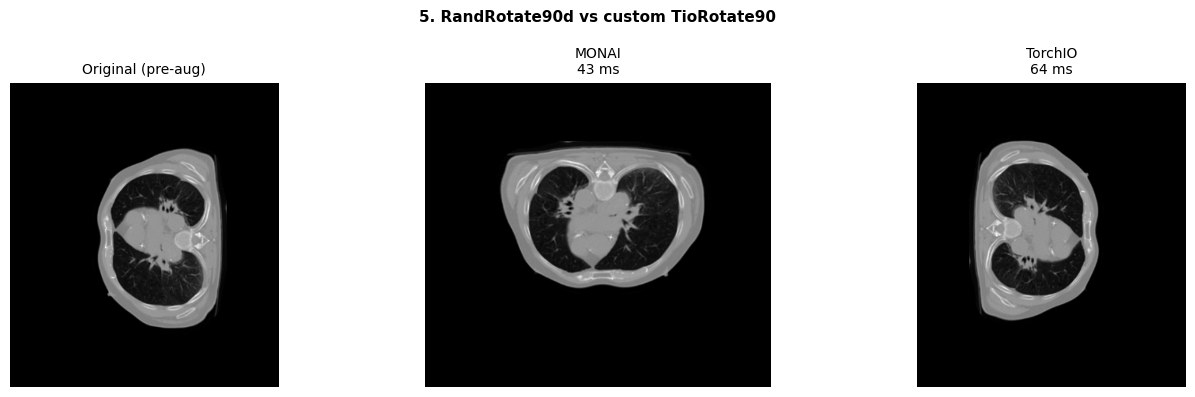

In [8]:
show(
    "5. RandRotate90d vs custom TioRotate90",
    RandRotate90d(keys=["image", "label"], prob=1.0, max_k=3, spatial_axes=(0, 1)),
    TioRotate90(),
)

---
## 6. RandSimulateLowResolutiond vs tio.RandomAnisotropy
MONAI: zoom_range=(0.25, 1.0) → TorchIO: downsampling=(1.5, 4).  
MONAI downsamples all axes uniformly; TorchIO picks one axis.

MONAI: 106.1 ms  |  TorchIO: 897.6 ms  (avg 3 runs)


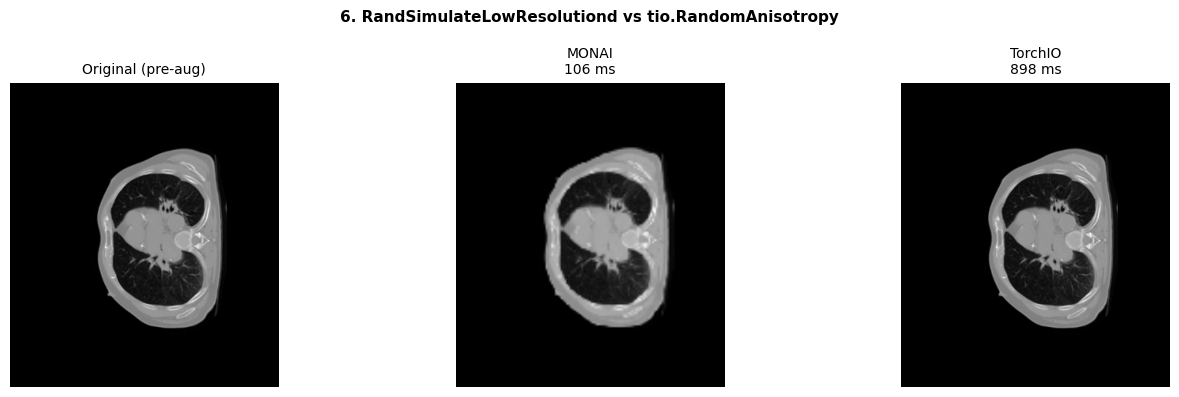

In [9]:
show(
    "6. RandSimulateLowResolutiond vs tio.RandomAnisotropy",
    RandSimulateLowResolutiond(keys="image", prob=1.0, zoom_range=(0.25, 1.0)),
    tio.RandomAnisotropy(downsampling=(1.5, 4), p=1.0),
)

---
## 7. RandGaussianNoised vs tio.RandomNoise

MONAI: 1109.3 ms  |  TorchIO: 298.1 ms  (avg 3 runs)


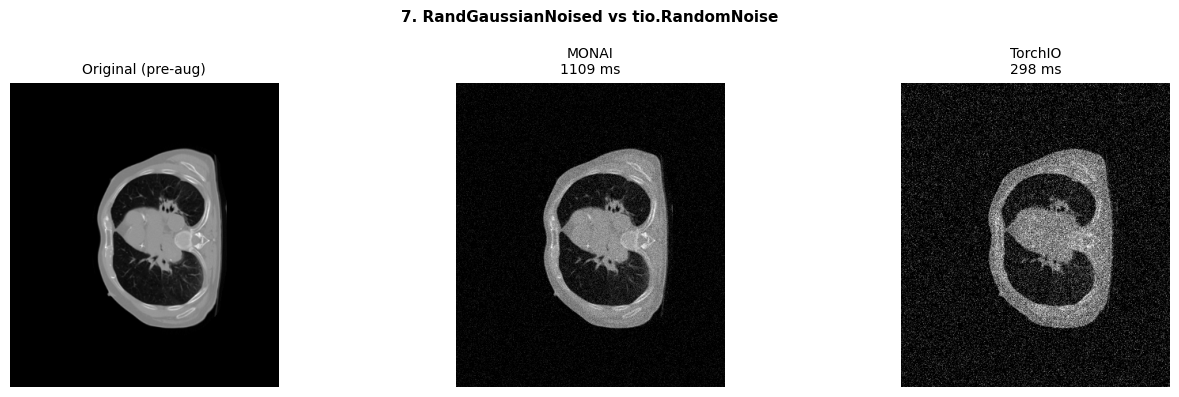

In [10]:
show(
    "7. RandGaussianNoised vs tio.RandomNoise",
    RandGaussianNoised(keys="image", prob=1.0),
    tio.RandomNoise(p=1.0),
)

---
## 8. RandBiasFieldd vs tio.RandomBiasField
`coeff_range=(0.0, 0.1)` → subtle bias (designed for MRI, applied to CT here).

MONAI: 1490.6 ms  |  TorchIO: 17529.3 ms  (avg 3 runs)


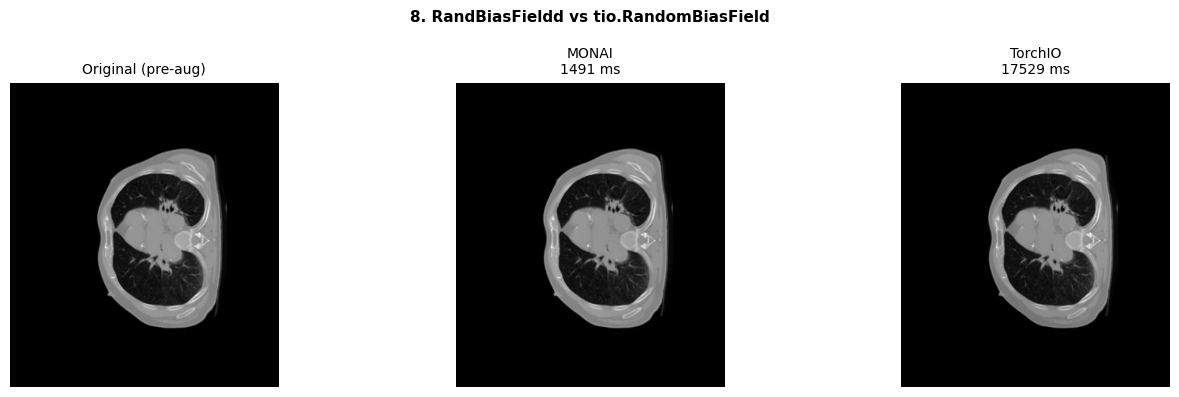

In [11]:
show(
    "8. RandBiasFieldd vs tio.RandomBiasField",
    RandBiasFieldd(keys="image", prob=1.0, coeff_range=(0.0, 0.1)),
    tio.RandomBiasField(coefficients=0.1, order=3, include=["image"]),
)

---
## 9. RandGibbsNoised vs tio.RandomGhosting
⚠️ **Different artifacts:** Gibbs ringing (k-space truncation) ≠ motion ghosting.  
Closest TorchIO option — compare visually.

MONAI: 1204.4 ms  |  TorchIO: 851.5 ms  (avg 3 runs)


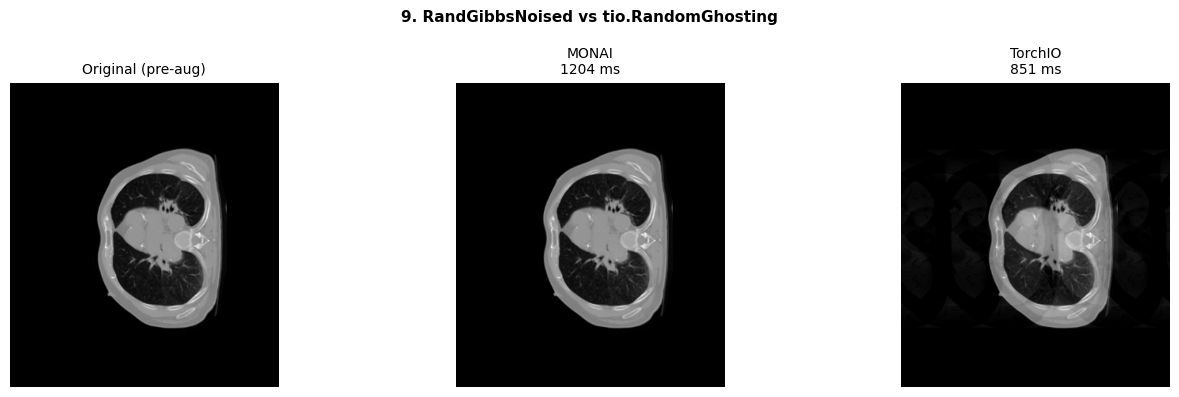

In [12]:
show(
    "9. RandGibbsNoised vs tio.RandomGhosting",
    RandGibbsNoised(keys="image", prob=1.0, alpha=(0.0, 0.33)),
    tio.RandomGhosting(num_ghosts=(4, 10), axes=(0, 1, 2), intensity=(0.5, 1.0), p=1.0, include=["image"]),
)

---
## 10. RandAdjustContrastd vs tio.RandomGamma
Both apply a power-law intensity mapping (gamma correction).

MONAI: 182.4 ms  |  TorchIO: 198.1 ms  (avg 3 runs)


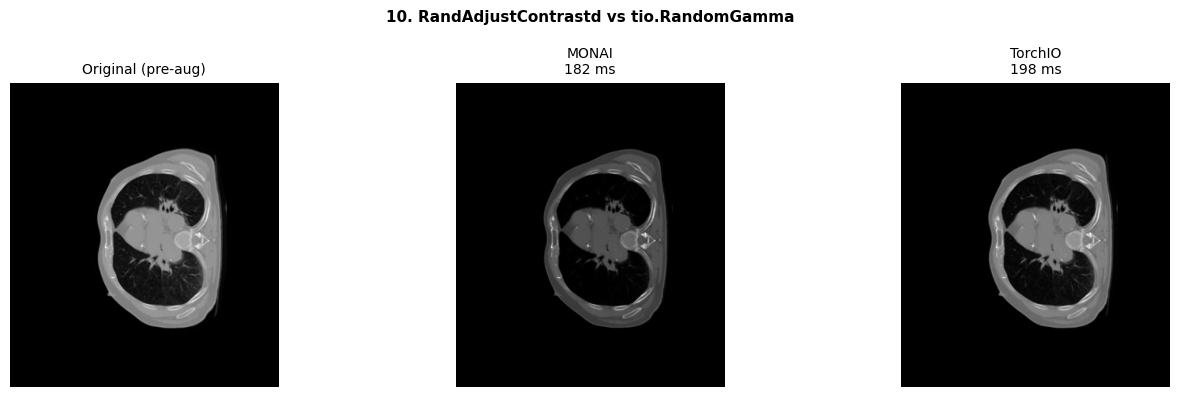

In [13]:
show(
    "10. RandAdjustContrastd vs tio.RandomGamma",
    RandAdjustContrastd(keys="image", prob=1.0),
    tio.RandomGamma(log_gamma=(-0.3, 0.3), p=1.0, include=["image"]),
)

---
## 11. RandGaussianSmoothd vs tio.RandomBlur
sigma=(0.0, 0.1) is very subtle. TorchIO std is in mm; MONAI sigma is in voxels.

MONAI: 2016.1 ms  |  TorchIO: 404.1 ms  (avg 3 runs)


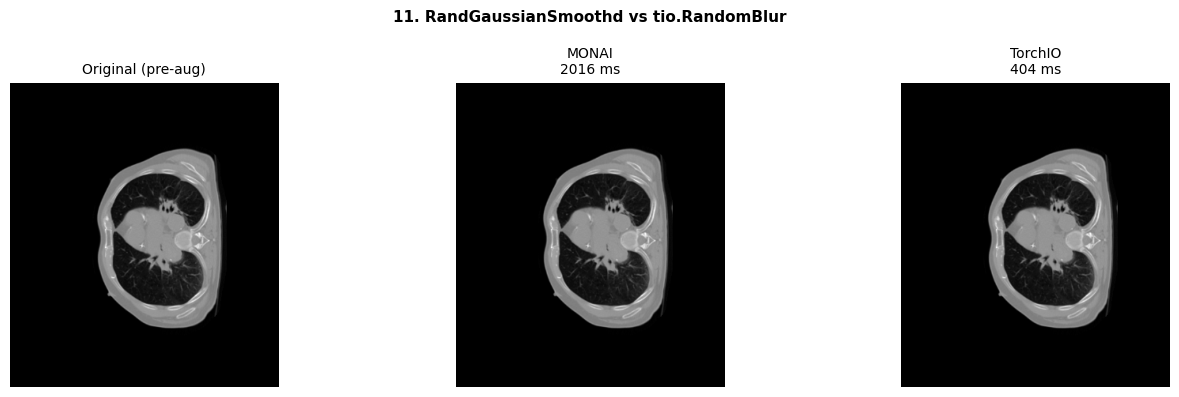

In [14]:
show(
    "11. RandGaussianSmoothd vs tio.RandomBlur",
    RandGaussianSmoothd(keys="image", prob=1.0, sigma_x=(0.0, 0.1), sigma_y=(0.0, 0.1), sigma_z=(0.0, 0.1)),
    tio.RandomBlur(std=(0.0, 0.1), p=1.0, include=["image"]),
)

---
## 12. RandGaussianSharpend vs custom TioGaussianSharpen
TorchIO has no built-in sharpening — custom unsharp masking: `image + α*(image − blurred)`.

MONAI: 3480.5 ms  |  TorchIO: 861.7 ms  (avg 3 runs)


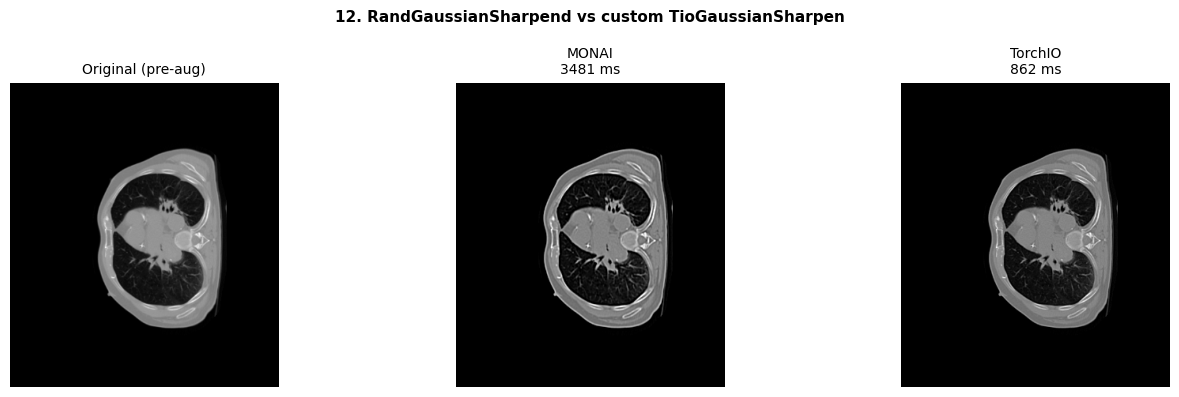

In [15]:
show(
    "12. RandGaussianSharpend vs custom TioGaussianSharpen",
    RandGaussianSharpend(keys="image", prob=1.0),
    TioGaussianSharpen(sigma=(0.5, 1.5), alpha=(0.5, 1.5)),
)

---
## 13. RandAffined vs tio.RandomAffine
MONAI: rotate ±45°, scale ±20%, shear ±0.2, crops output to 128³.  
TorchIO: same params but keeps original volume shape.

MONAI: 3123.6 ms  |  TorchIO: 1582.0 ms  (avg 3 runs)


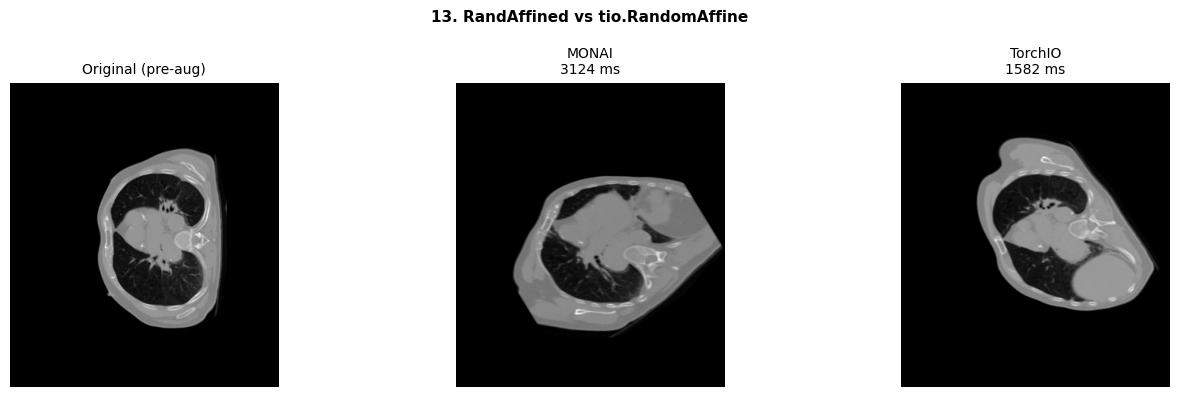

In [19]:
show(
    "13. RandAffined vs tio.RandomAffine",
    RandAffined(
        keys=["image", "label"],
        prob=1.0,
        mode=("bilinear", "nearest"),
        rotate_range=(np.pi / 4, np.pi / 4, np.pi / 4),
        scale_range=(0.2, 0.2, 0.2),
        shear_range=(0.2, 0.2, 0.2),
        # spatial_size=CROP_SIZE,
        padding_mode="zeros",
    ),
    tio.RandomAffine(
        scales=(0.8, 1.2),
        degrees=45,
        p=1.0,
    ),
)

---
## Summary timing

Transform                                             MONAI (ms)  TorchIO (ms)   Winner
----------------------------------------------------------------------------------------
1. Spacingd vs tio.Resample                                 21.6        1160.5    MONAI
2. SpatialPadd vs tio.CropOrPad                             12.5          25.2    MONAI
3. ScaleIntensityRanged vs tio.RescaleIntensity            114.3         773.0    MONAI
4. RandAxisFlipd vs tio.RandomFlip                          44.6          94.5    MONAI
5. RandRotate90d vs custom TioRotate90                      43.1          64.0    MONAI
6. RandSimulateLowResolutiond vs tio.RandomAnisotropy       106.1         897.6    MONAI
7. RandGaussianNoised vs tio.RandomNoise                  1109.3         298.1  TorchIO
8. RandBiasFieldd vs tio.RandomBiasField                  1490.6       17529.3    MONAI
9. RandGibbsNoised vs tio.RandomGhosting                  1204.4         851.5  TorchIO
10. RandAdjustContrastd vs tio

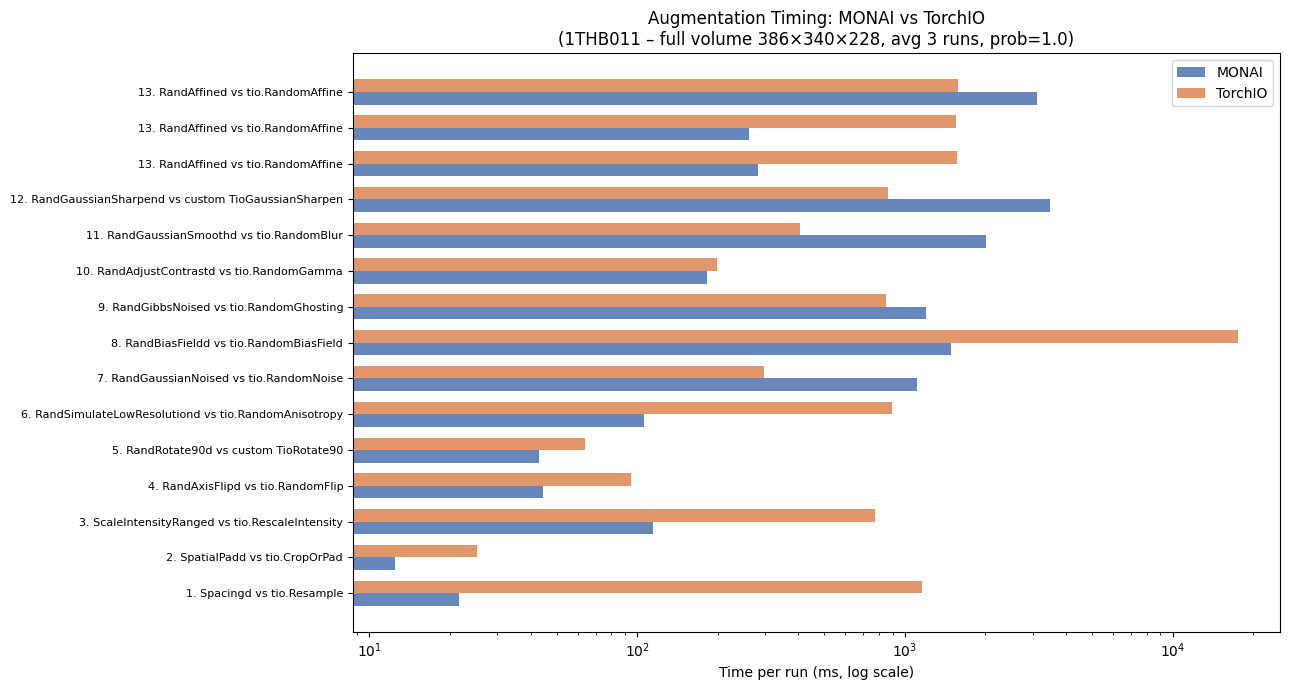

In [20]:
print(f"{'Transform':<52} {'MONAI (ms)':>11} {'TorchIO (ms)':>13} {'Winner':>8}")
print("-" * 88)
for name, m_ms, t_ms in results:
    winner = "TorchIO" if t_ms < m_ms else "MONAI"
    print(f"{name:<52} {m_ms:>11.1f} {t_ms:>13.1f} {winner:>8}")

fig, ax = plt.subplots(figsize=(13, 7))
labels = [r[0] for r in results]
monai_ms = [r[1] for r in results]
tio_ms = [r[2] for r in results]
x = np.arange(len(labels))
w = 0.35
ax.barh(x - w / 2, monai_ms, w, label="MONAI", color="#4C72B0", alpha=0.85)
ax.barh(x + w / 2, tio_ms, w, label="TorchIO", color="#DD8452", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Time per run (ms, log scale)")
ax.set_title(f"Augmentation Timing: MONAI vs TorchIO\n(1THB011 – full volume 386×340×228, avg {N_RUNS} runs, prob=1.0)")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.savefig(OUT_DIR / "summary_timing.png", dpi=150, bbox_inches="tight")
plt.show()